In [8]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, classification_report, accuracy_score
from lightgbm import LGBMClassifier

# 1. Define Features
cat_cols = ['EmploymentStatus', 'Occupation', 'BorrowerState', 'ProsperRating (Alpha)', 'IncomeRange']
num_cols = [
    'Term', 'ListingCategory (numeric)', 'EmploymentStatusDuration', 'StatedMonthlyIncome',
    'DebtToIncomeRatio', 'IsBorrowerHomeowner', 'IncomeVerifiable', 'CreditScoreRangeLower',
    'CreditScoreRangeUpper', 'ProsperScore', 'ProsperRating (numeric)', 'CurrentCreditLines',
    'OpenCreditLines', 'TotalCreditLinespast7years', 'TotalTrades', 'OpenRevolvingAccounts',
    'OpenRevolvingMonthlyPayment', 'BankcardUtilization', 'AvailableBankcardCredit',
    'RevolvingCreditBalance', 'TradesNeverDelinquent (percentage)', 'CurrentDelinquencies',
    'DelinquenciesLast7Years'
]
features_28 = cat_cols + num_cols

# 2. Load Dataset
df = pd.read_csv(r"D:\Koding Liburan\Full Dataset\prosperloandata_28_fitur_large.csv", low_memory=False)

# Reconstruct categorical columns
if 'EmploymentStatus' not in df.columns:
    emp_cols = [c for c in df.columns if c.startswith("EmploymentStatus_") and c != "EmploymentStatusDuration"]
    df['EmploymentStatus'] = "Other"
    for col in emp_cols:
        df.loc[df[col] == 1, 'EmploymentStatus'] = col.replace("EmploymentStatus_", "")

if 'IncomeRange' not in df.columns:
    inc_cols = [c for c in df.columns if c.startswith("IncomeRange_")]
    df['IncomeRange'] = "$25,000-49,999"
    for col in inc_cols:
        df.loc[df[col] == 1, 'IncomeRange'] = col.replace("IncomeRange_", "")

if 'ProsperRating (Alpha)' not in df.columns:
    rating_map = {1: 'HR', 2: 'E', 3: 'D', 4: 'C', 5: 'B', 6: 'A', 7: 'AA'}
    df['ProsperRating (Alpha)'] = df['ProsperRating (numeric)'].round().fillna(4).map(rating_map).fillna('C')

for col in cat_cols:
    df[col] = df[col].astype(str)

# 3. Map Target Klasifikasi (1 = ACC, 0 = REJECT)
df['LoanApprovalStatus'] = df['LoanStatus'].apply(lambda x: 1 if x in ['Completed', 'Current', 'FinalPaymentInProgress'] else 0)

# 4. Split Train/Val
X_clf = df[features_28]
y_clf = df['LoanApprovalStatus'].values
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# 5. Pipeline Preprocessing & Model Baseline
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), 
                      ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), cat_cols)
], remainder='drop')

pipe_klasifikasi = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1))
])

# 6. Train & Evaluate
print("Training Classification Model (Baseline)...")
pipe_klasifikasi.fit(X_train_clf, y_train_clf)
y_proba = pipe_klasifikasi.predict_proba(X_val_clf)[:, 1]

best_thresh, best_f1 = 0.5, 0
for th in np.arange(0.3, 0.8, 0.01):
    f1 = f1_score(y_val_clf, y_proba >= th)
    if f1 > best_f1:
        best_f1, best_thresh = f1, th

y_pred_clf = (y_proba >= best_thresh).astype(int)
print(f"Optimal Threshold: {best_thresh:.4f}")
print(f"Accuracy: {accuracy_score(y_val_clf, y_pred_clf):.4%}")
print("\nClassification Report:\n", classification_report(y_val_clf, y_pred_clf, target_names=['REJECT', 'ACC']))

Training Classification Model (Baseline)...
Optimal Threshold: 0.4900
Accuracy: 84.7244%

Classification Report:
               precision    recall  f1-score   support

      REJECT       0.67      0.19      0.30      3863
         ACC       0.86      0.98      0.91     18925

    accuracy                           0.85     22788
   macro avg       0.76      0.59      0.61     22788
weighted avg       0.82      0.85      0.81     22788



Menghitung Learning Curve Klasifikasi...


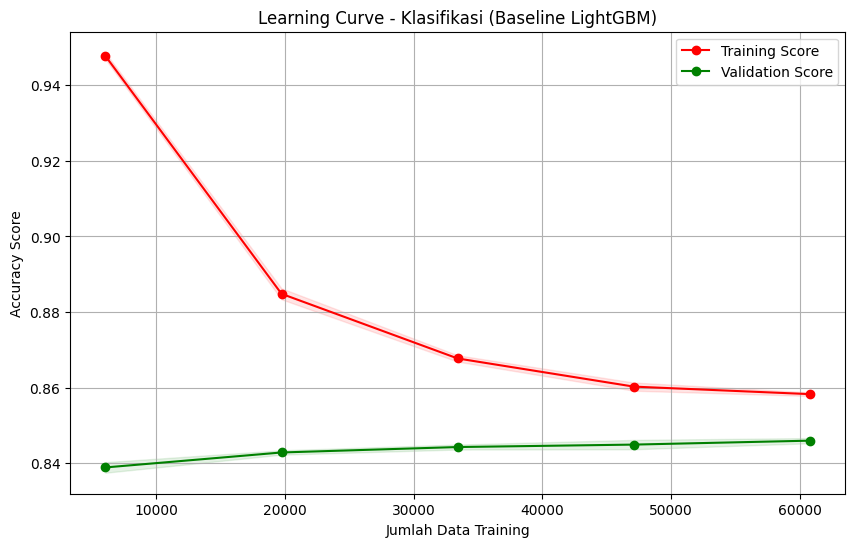

In [9]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

print("Menghitung Learning Curve Klasifikasi...")
train_sizes_req = np.linspace(0.1, 1.0, 5)
train_sizes_clf, train_scores_clf, test_scores_clf = learning_curve(
    pipe_klasifikasi, X_train_clf, y_train_clf, 
    cv=3, scoring='accuracy', n_jobs=-1, train_sizes=train_sizes_req
)

train_mean_clf = np.mean(train_scores_clf, axis=1)
train_std_clf = np.std(train_scores_clf, axis=1)
test_mean_clf = np.mean(test_scores_clf, axis=1)
test_std_clf = np.std(test_scores_clf, axis=1)

plt.figure(figsize=(10, 6))
plt.title("Learning Curve - Klasifikasi (Baseline LightGBM)")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Accuracy Score")
plt.grid()
plt.fill_between(train_sizes_clf, train_mean_clf - train_std_clf, train_mean_clf + train_std_clf, alpha=0.1, color="r")
plt.fill_between(train_sizes_clf, test_mean_clf - test_std_clf, test_mean_clf + test_std_clf, alpha=0.1, color="g")
plt.plot(train_sizes_clf, train_mean_clf, 'o-', color="r", label="Training Score")
plt.plot(train_sizes_clf, test_mean_clf, 'o-', color="g", label="Validation Score")
plt.legend(loc="best")
plt.show()

In [10]:
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Filter ACC Only (Mencegah Kebocoran Data)
df_acc = df[df['LoanApprovalStatus'] == 1].copy()
df_acc = df_acc.dropna(subset=['LoanOriginalAmount'])

X_reg = df_acc[features_28]
y_reg = df_acc['LoanOriginalAmount'].values
X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 2. Definisikan 5 Model Baseline (TANPA TUNING)
models = {
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Bayesian Ridge": BayesianRidge()
}

hasil_evaluasi = []
best_r2 = -float('inf')
best_model_name = ""
best_pipeline_reg = None

print("Melatih 5 Model Regresi (Baseline)...")
for nama_model, algoritma in models.items():
    print(f"-> Training {nama_model}...")
    pipe_reg = Pipeline([
        ('preprocessor', preprocessor), # REUSE preprocessor dari Cell 1
        ('model', algoritma)
    ])
    
    pipe_reg.fit(X_train_reg, y_train_reg)
    y_pred_reg = pipe_reg.predict(X_val_reg)
    
    r2 = r2_score(y_val_reg, y_pred_reg)
    mae = mean_absolute_error(y_val_reg, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred_reg))
    
    hasil_evaluasi.append({"Algoritma": nama_model, "R2 Score": r2, "MAE": mae, "RMSE": rmse})
    
    if r2 > best_r2:
        best_r2 = r2
        best_model_name = nama_model
        best_pipeline_reg = pipe_reg

df_hasil = pd.DataFrame(hasil_evaluasi).sort_values(by="R2 Score", ascending=False)
print("\n=== LEADERBOARD REGRESI (BASELINE) ===")
pd.options.display.float_format = '{:,.4f}'.format
print(df_hasil.to_string(index=False))
print(f"\nModel Terbaik Sementara yang akan di-plot: {best_model_name}")

Melatih 5 Model Regresi (Baseline)...
-> Training LightGBM...
-> Training Random Forest...
-> Training Extra Trees...
-> Training Gradient Boosting...
-> Training Bayesian Ridge...

=== LEADERBOARD REGRESI (BASELINE) ===
        Algoritma  R2 Score        MAE       RMSE
         LightGBM    0.5964 2,917.1967 4,019.2339
      Extra Trees    0.5961 2,876.3181 4,020.8107
    Random Forest    0.5836 2,918.2547 4,082.6574
Gradient Boosting    0.5441 3,138.4016 4,271.4808
   Bayesian Ridge    0.4318 3,590.7892 4,768.7037

Model Terbaik Sementara yang akan di-plot: LightGBM


Menghitung Learning Curve Regresi untuk model terbaik (LightGBM)...


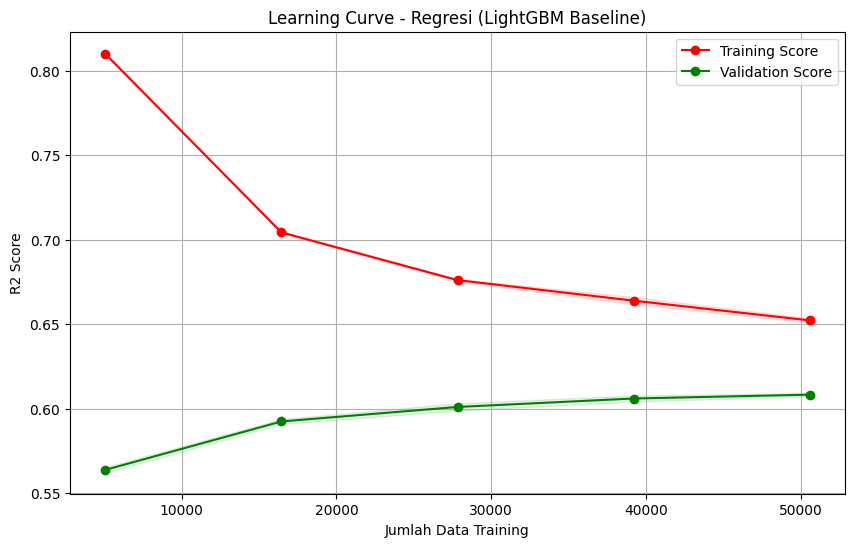

In [11]:
print(f"Menghitung Learning Curve Regresi untuk model terbaik ({best_model_name})...")
train_sizes_reg, train_scores_reg, test_scores_reg = learning_curve(
    best_pipeline_reg, X_train_reg, y_train_reg, 
    cv=3, scoring='r2', n_jobs=-1, train_sizes=train_sizes_req
)

train_mean_reg = np.mean(train_scores_reg, axis=1)
train_std_reg = np.std(train_scores_reg, axis=1)
test_mean_reg = np.mean(test_scores_reg, axis=1)
test_std_reg = np.std(test_scores_reg, axis=1)

plt.figure(figsize=(10, 6))
plt.title(f"Learning Curve - Regresi ({best_model_name} Baseline)")
plt.xlabel("Jumlah Data Training")
plt.ylabel("R2 Score")
plt.grid()
plt.fill_between(train_sizes_reg, train_mean_reg - train_std_reg, train_mean_reg + train_std_reg, alpha=0.1, color="r")
plt.fill_between(train_sizes_reg, test_mean_reg - test_std_reg, test_mean_reg + test_std_reg, alpha=0.1, color="g")
plt.plot(train_sizes_reg, train_mean_reg, 'o-', color="r", label="Training Score")
plt.plot(train_sizes_reg, test_mean_reg, 'o-', color="g", label="Validation Score")
plt.legend(loc="best")
plt.show()

Memulai Hyperparameter Tuning (Mode Anti-Overfitting)...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

 HASIL TUNING (ANTI-OVERFITTING)
Kombinasi Parameter Terbaik:
{'model__subsample': 0.8, 'model__reg_lambda': 1.0, 'model__reg_alpha': 1.0, 'model__num_leaves': 15, 'model__n_estimators': 300, 'model__min_child_samples': 30, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.6}

R2 Score Baru   : 0.5828 (Sebelumnya: 0.5964)
MAE Baru        : $2,973.69
RMSE Baru       : $4,086.25

Membuat Learning Curve baru...


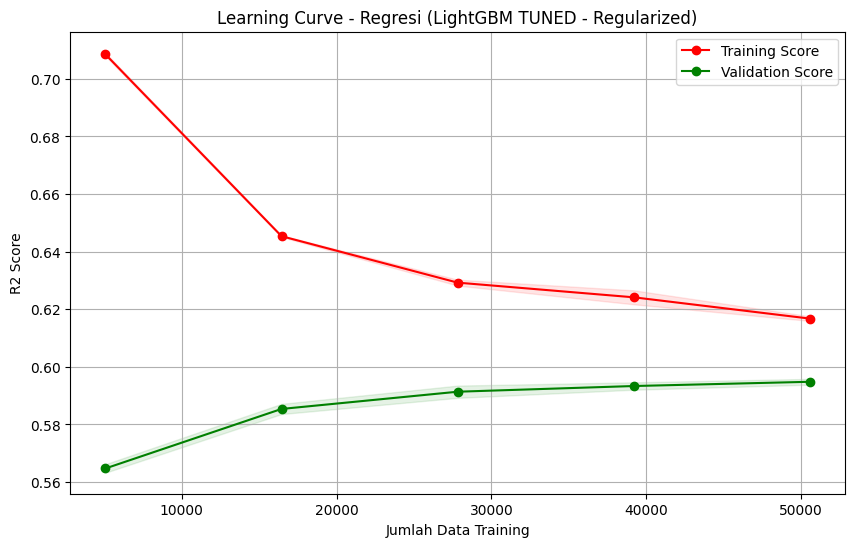

In [12]:
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt

print("Memulai Hyperparameter Tuning (Mode Anti-Overfitting)...")

# 1. Parameter Grid yang difokuskan untuk MENCEGAH Overfitting
param_dist = {
    'model__n_estimators': [100, 200, 300],             # Jangan terlalu banyak pohon
    'model__learning_rate': [0.01, 0.05],               # Belajar pelan-pelan
    'model__max_depth': [3, 4, 5],                      # POHON DIBIKIN DANGKAL (Kunci cegah overfit)
    'model__num_leaves': [10, 15, 31],                  # Daun dibatasi
    'model__min_child_samples': [30, 50, 100],          # Minimal data per daun digedein biar general
    'model__subsample': [0.6, 0.8],                     
    'model__colsample_bytree': [0.6, 0.8],              
    'model__reg_alpha': [0.1, 1.0, 5.0, 10.0],          # L1 Regularization (Biar fitur ga penting dibuang)
    'model__reg_lambda': [0.1, 1.0, 5.0, 10.0]          # L2 Regularization (Ngerem model biar ga overfit)
}

# 2. Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    best_pipeline_reg, # Pastikan ini ditarik dari hasil Cell 3 lu
    param_distributions=param_dist, 
    n_iter=40,         # Coba 40 kombinasi
    cv=3, 
    scoring='r2', 
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 3. Eksekusi Tuning
random_search.fit(X_train_reg, y_train_reg)

# 4. Evaluasi Model Baru
best_lgbm_tuned = random_search.best_estimator_
y_pred_tuned = best_lgbm_tuned.predict(X_val_reg)

r2_new = r2_score(y_val_reg, y_pred_tuned)
mae_new = mean_absolute_error(y_val_reg, y_pred_tuned)
rmse_new = np.sqrt(mean_squared_error(y_val_reg, y_pred_tuned))

print("\n" + "="*40)
print(" HASIL TUNING (ANTI-OVERFITTING)")
print("="*40)
print(f"Kombinasi Parameter Terbaik:\n{random_search.best_params_}\n")
print(f"R2 Score Baru   : {r2_new:.4f} (Sebelumnya: {best_r2:.4f})")
print(f"MAE Baru        : ${mae_new:,.2f}")
print(f"RMSE Baru       : ${rmse_new:,.2f}") # <--- INI TAMBAHANNYA BRE
print("="*40)

joblib.dump(best_lgbm_tuned, "model_regresi_tuned_final.pkl")

# =====================================================================
# BIKIN LEARNING CURVE BARU UNTUK CEK KESEHATAN MODEL
# =====================================================================
print("\nMembuat Learning Curve baru...")

# Panggil np.linspace kalau sebelumnya belum di-define
import numpy as np
from sklearn.model_selection import learning_curve

train_sizes_req = np.linspace(0.1, 1.0, 5)

train_sizes_tune, train_scores_tune, test_scores_tune = learning_curve(
    best_lgbm_tuned, X_train_reg, y_train_reg, 
    cv=3, scoring='r2', n_jobs=-1, train_sizes=train_sizes_req
)

train_mean_tune = np.mean(train_scores_tune, axis=1)
train_std_tune = np.std(train_scores_tune, axis=1)
test_mean_tune = np.mean(test_scores_tune, axis=1)
test_std_tune = np.std(test_scores_tune, axis=1)

plt.figure(figsize=(10, 6))
plt.title("Learning Curve - Regresi (LightGBM TUNED - Regularized)")
plt.xlabel("Jumlah Data Training")
plt.ylabel("R2 Score")
plt.grid()
plt.fill_between(train_sizes_tune, train_mean_tune - train_std_tune, train_mean_tune + train_std_tune, alpha=0.1, color="r")
plt.fill_between(train_sizes_tune, test_mean_tune - test_std_tune, test_mean_tune + test_std_tune, alpha=0.1, color="g")
plt.plot(train_sizes_tune, train_mean_tune, 'o-', color="r", label="Training Score")
plt.plot(train_sizes_tune, test_mean_tune, 'o-', color="g", label="Validation Score")
plt.legend(loc="best")
plt.show()